In [1]:
!pip install -q transformers torch

In [2]:
from huggingface_hub import notebook_login
import pandas as pd
from transformers import pipeline
import matplotlib.pyplot as plt

In [3]:
# LOGIN EN HUGGINGFACE
notebook_login()

In [4]:
# Load the CSV file into a DataFrame
df = pd.read_csv("/content/datos APPL.csv")

# Display the first 5 rows of the DataFrame
print("Primeras 5 filas del DataFrame:")
display(df.head())

Primeras 5 filas del DataFrame:


,ID_Tweet,Fecha_UTC,Contenido_Texto,Retweets,Favoritos
0,2043795550336680030,2026-04-13T20:56:45.000Z,Imagina ter investido $1.000 na Apple ($AAPL) ...,0,0
1,2043791645422796884,2026-04-13T20:41:14.000Z,ALERT: Market data suggests a broad divergence...,0,0
2,2043790960794931689,2026-04-13T20:38:31.000Z,Apple is closing up one of its first US stores...,0,0
3,2043788966533664823,2026-04-13T20:30:36.000Z,"Apple TV's 'The Husbands': Joe Alwyn, Richard ...",0,0
4,2043786269369741628,2026-04-13T20:19:52.000Z,✦ Musician loses significant Bitcoin $BTC reti...,0,0


# ANALISIS DE SENTIMIENTO

Realizamos el analisis de sentimiento utilizando el modelo CardiffNLP especializado en el lenguaje de la red social X.

Ahora que hemos cargado los datos, vamos a verificar la columna `Contenido_Texto` y a preparar el entorno para el análisis de sentimiento utilizando un modelo especializado en lenguaje de redes sociales. Para esto, usaremos la librería `transformers` de Hugging Face y un modelo como `cardiffnlp/twitter-roberta-base-sentiment-latest`, que es adecuado para tweets y texto de redes sociales.

Primero, instalaremos las librerías necesarias.

In [8]:
# Initialize the sentiment analysis pipeline with the recommended model for social media
sentiment_analyzer = pipeline(
    "sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment-latest"
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [11]:
# VAMOS A REPRODUCIR EL PROCESO DE ANALISIS DE SENTIMIENTOS SOBRE DOS FILAS DEL
# DATAFRAME PARA OBSERVAR COMO SE COMPORTA
df_sample = df.head(2).copy()

df_sample["Sentimiento"] = (
    df_sample["Contenido_Texto"]
    .astype(str)
    .apply(lambda x: sentiment_analyzer(x)[0]["label"])
)
df_sample["Puntuacion_Sentimiento"] = (
    df_sample["Contenido_Texto"]
    .astype(str)
    .apply(lambda x: sentiment_analyzer(x)[0]["score"])
)

df_sample

,ID_Tweet,Fecha_UTC,Contenido_Texto,Retweets,Favoritos,Sentimiento,Puntuacion_Sentimiento
0,2043795550336680030,2026-04-13T20:56:45.000Z,Imagina ter investido $1.000 na Apple ($AAPL) ...,0,0,neutral,0.792935
1,2043791645422796884,2026-04-13T20:41:14.000Z,ALERT: Market data suggests a broad divergence...,0,0,positive,0.580023


In [12]:
# Apply sentiment analysis to the 'Contenido_Texto' column
# We'll handle potential NaN values by converting them to empty strings or filtering them
df["Sentimiento"] = (
    df["Contenido_Texto"].astype(str).apply(lambda x: sentiment_analyzer(x)[0]["label"])
)
df["Puntuacion_Sentimiento"] = (
    df["Contenido_Texto"].astype(str).apply(lambda x: sentiment_analyzer(x)[0]["score"])
)

In [13]:
print("\nPrimeras 5 filas con el sentimiento analizado:")
display(df[["Contenido_Texto", "Sentimiento", "Puntuacion_Sentimiento"]].head())

# Display the distribution of sentiments
print("\nDistribución de Sentimientos:")
display(df["Sentimiento"].value_counts())


Primeras 5 filas con el sentimiento analizado:


,Contenido_Texto,Sentimiento,Puntuacion_Sentimiento
0,Imagina ter investido $1.000 na Apple ($AAPL) ...,neutral,0.792935
1,ALERT: Market data suggests a broad divergence...,positive,0.580023
2,Apple is closing up one of its first US stores...,neutral,0.645463
3,"Apple TV's 'The Husbands': Joe Alwyn, Richard ...",neutral,0.840060
4,✦ Musician loses significant Bitcoin $BTC reti...,negative,0.771509



Distribución de Sentimientos:


,count
Sentimiento,
neutral,5128
positive,2480
negative,573


# MUESTRA DEL SENTIMIENTO POR DÍA

Mostramos el sentimiento general en torno a Apple por cada día analizado.


--- Muestra del Análisis de Sentimiento --- 


,Contenido_Texto,Sentimiento,Puntuacion_Sentimiento
7400,There is a growing theory that companies who h...,positive,0.769857
6268,"$AAPL BofA raises Apple price target to $325, ...",positive,0.846292
787,Short $AAPL if true,neutral,0.773767
2074,"$AAPL ALERT: Big Block Trade! $2,969,040 in pr...",neutral,0.593807
6308,✦ Musician loses significant Bitcoin $BTC reti...,negative,0.771509


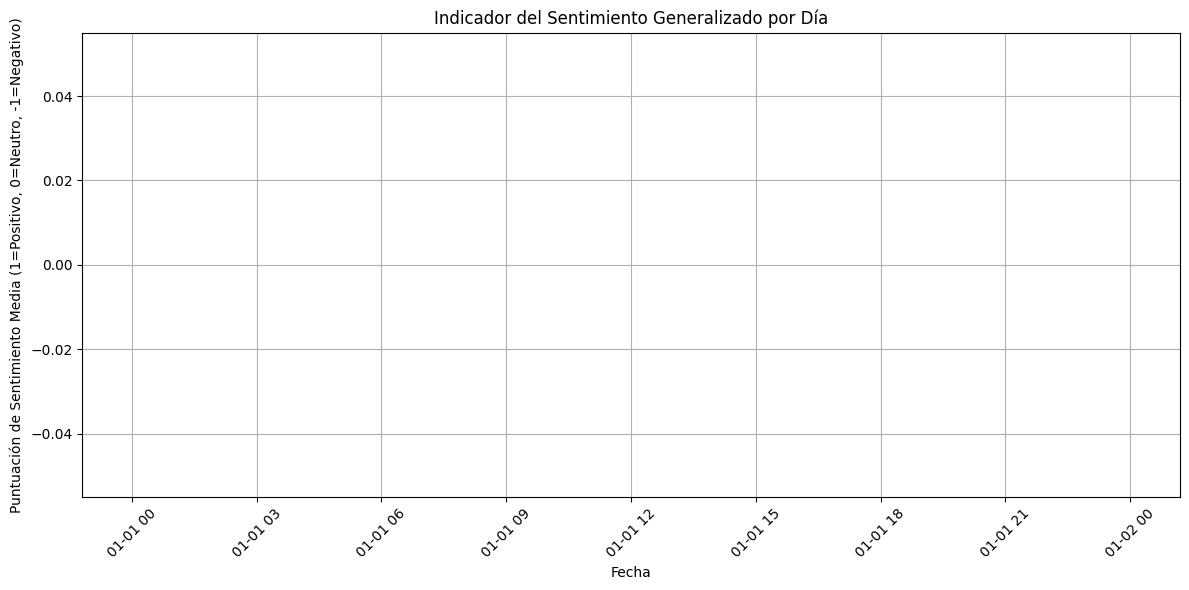

In [16]:
# Display a sample of the sentiment analysis results
print("\n--- Muestra del Análisis de Sentimiento --- ")
display(df[["Contenido_Texto", "Sentimiento", "Puntuacion_Sentimiento"]].sample(5))

df["Fecha_UTC"] = pd.to_datetime(df["Fecha_UTC"])

# Map sentiment labels to numerical scores
sentiment_mapping = {"Positive": 1, "Neutral": 0, "Negative": -1}
df["Sentiment_Score"] = df["Sentimiento"].map(sentiment_mapping)

# Aggregate sentiment by day
daily_sentiment = (
    df.groupby(df["Fecha_UTC"].dt.date)["Sentiment_Score"].mean().reset_index()
)
daily_sentiment.rename(columns={"Fecha_UTC": "Date"}, inplace=True)

# Plot the daily aggregated sentiment
plt.figure(figsize=(12, 6))
plt.plot(
    daily_sentiment["Date"],
    daily_sentiment["Sentiment_Score"],
    marker="o",
    linestyle="-",
)
plt.title("Indicador del Sentimiento Generalizado por Día")
plt.xlabel("Fecha")
plt.ylabel("Puntuación de Sentimiento Media (1=Positivo, 0=Neutro, -1=Negativo)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
# Persist the DataFrame to a new CSV file
df.to_csv("/content/df_sentimiento_analizado.csv", index=False)
print("DataFrame guardado exitosamente en '/content/df_sentimiento_analizado.csv'")

DataFrame guardado exitosamente en '/content/df_sentimiento_analizado.csv'
